### Tools
Models can request to call tools that perform tasks such as fetching data from databse, searching the web, or running code. Tools are pairing of:

1. A schema, including the name of the tool, a description, and/or argument definitions (often a JSON schema)
2. A function of coroutine to execute.

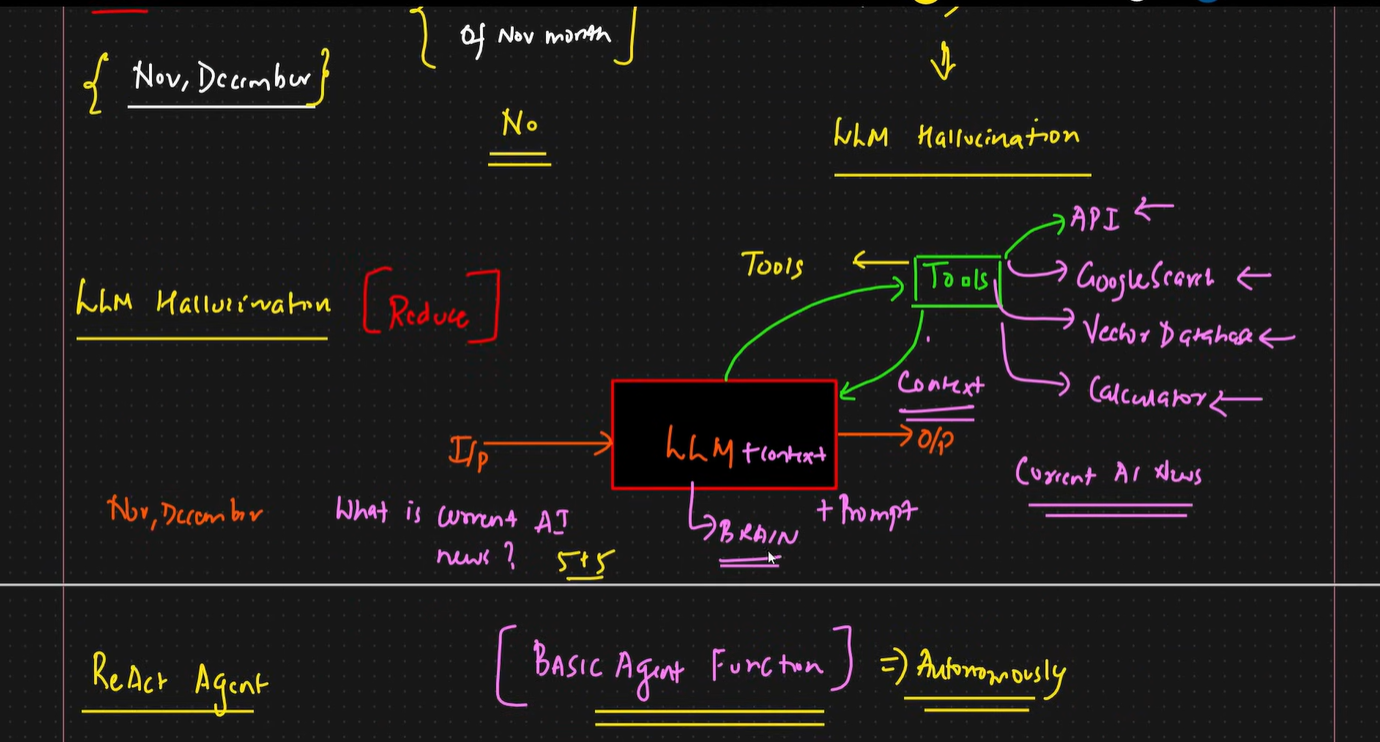

**NOTE: LLM Hallucination happens bcz of the tendency of a LLM to give the output at any scenario weather it is right or wronge. Suppose your LLM knows everything about Cat but nothing about a Dog and you asks it about dog. In this scenario, the LLM is knowing nothing but bcz of it's tendency it will give fake/wrong output and this is called as LLM Hallucination where LLM gives wrong answer with confidence.**

In [1]:
import os
from langchain.chat_models import init_chat_model
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [29]:
model = init_chat_model(
    "groq:qwen/qwen3-32b"
)
response=model.invoke("Write me an essay on AI")
response

AIMessage(content="<think>\nOkay, the user wants an essay on AI. Let me start by understanding the scope. AI is a broad topic, so I need to narrow it down. Maybe focus on its impact across different areas like technology, economy, society, and ethics. \n\nFirst, I should define AI. What is it? Machine learning, neural networks, algorithms that can perform tasks requiring human intelligence. Examples like speech recognition, decision-making. \n\nNext, historical context. When did AI start? The Turing Test, early developments in the 1950s. Then the AI winter, and recent resurgence with big data and computational power. \n\nApplications are important. Healthcare, finance, transportation. Maybe mention specific examples like AI in diagnostics or autonomous vehicles. \n\nEconomic impact: job displacement vs creation. Need to mention both sides. Also, the gig economy and new job roles. \n\nEthical considerations. Bias in AI algorithms, data privacy, surveillance. The example with facial reco

#### Tools

In [31]:
# we will use Decorator to create a Tool

from langchain.tools import tool

@tool
def get_weather(location:str)->str:
    """Get the weather at a location"""
    return f"It's sunny in {location}"

model_with_tools=model.bind_tools([get_weather])

In [32]:
response = model_with_tools.invoke("What's the weather like in Boston?")
print(response)

content='' additional_kwargs={'reasoning_content': "Okay, the user is asking about the weather in Boston. I need to use the get_weather function. Let me check the function parameters. It requires a location, which in this case is Boston. So I'll call the function with location set to Boston. Make sure the JSON is correctly formatted with the name and arguments. No other parameters are needed here. Just the location. Alright, that should do it.\n", 'tool_calls': [{'id': 'dz1c5yhdk', 'function': {'arguments': '{"location":"Boston"}', 'name': 'get_weather'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 107, 'prompt_tokens': 154, 'total_tokens': 261, 'completion_time': 0.179499225, 'completion_tokens_details': {'reasoning_tokens': 83}, 'prompt_time': 0.007041052, 'prompt_tokens_details': None, 'queue_time': 0.160939787, 'total_time': 0.186540277}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_2bfcc54d36', 'service_tier': 'on_demand', 'finish_rea

In [33]:
response.tool_calls

[{'name': 'get_weather',
  'args': {'location': 'Boston'},
  'id': 'dz1c5yhdk',
  'type': 'tool_call'}]

### Tool Execution Loop

In [34]:
# Step 1: Model generates tool calls
messages = [{"role": "user", "content": "What's the weather in Boston?"}]
ai_msg = model_with_tools.invoke(messages)
messages.append(ai_msg)

# Step 2: Execute tools and collect results
for tool_call in ai_msg.tool_calls:
    # Execute the tool with the generated arguments
    tool_result = get_weather.invoke(tool_call)
    messages.append(tool_result)

# Step 3: Pass results back to model for final response
final_response = model_with_tools.invoke(messages)
print(final_response.text)

The weather in Boston is sunny.


In [35]:
messages

[{'role': 'user', 'content': "What's the weather in Boston?"},
 AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for the weather in Boston. Let me check the tools available. There\'s a function called get_weather that takes a location parameter. Since the user specified Boston, I need to call that function with "Boston" as the location. I\'ll make sure to format the tool call correctly within the XML tags.\n', 'tool_calls': [{'id': '74vph99ar', 'function': {'arguments': '{"location":"Boston"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 91, 'prompt_tokens': 153, 'total_tokens': 244, 'completion_time': 0.133306192, 'completion_tokens_details': {'reasoning_tokens': 67}, 'prompt_time': 0.007676544, 'prompt_tokens_details': None, 'queue_time': 0.053664576, 'total_time': 0.140982736}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_re